# ESERCIZIO 2.1


In [1]:
# ── Import standard ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import fmfinance as fm
import quantstats as qs
import time
import random
import warnings

# statsmodels
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.regression.rolling import RollingOLS
from statsmodels.iolib.summary2 import summary_col
from statsmodels.datasets import longley

# scipy
from scipy.stats import norm
from scipy.stats import linregress
from scipy import stats

# datetime e pandas utils
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# PyPortfolioOpt (Es02)
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# Widget e display (Es02b, Es04b)
import ipywidgets as widgets
from IPython.display import display

# Web scraping (Es03c)
import requests
from bs4 import BeautifulSoup
from io import StringIO

# Soppressione warning
warnings.filterwarnings("ignore", category=FutureWarning)

import plotly.express as px

## PUNTO 1

In [2]:
# CELLA 2 — versione corretta
stoxx600 = pd.read_excel('stoxx600.xlsx', header=0)

start = '2017-01-01'
end   = '2025-12-31'

# Campionamento casuale di 111 titoli — seed obbligatorio: 777
random.seed(777)
random_tickers = random.sample(list(stoxx600['Tickers']), 111)

# Download prezzi mensili
prices = yf.download(
    random_tickers,
    start=start, end=end,
    auto_adjust=False,
    multi_level_index=False,
    interval='1mo'
)['Adj Close']

# Calcolo rendimenti percentuali mensili
rendimenti_grezzi = prices.pct_change() * 100

# Step 1: rimuovi PRIMA la prima riga (tutta NaN da pct_change)
# Step 2: poi rimuovi le colonne con NaN residui (ticker non scaricati)
returns = rendimenti_grezzi.dropna(how='all').dropna(axis=1)

[*************         27%                       ]  30 of 111 completed$KMAR.OL: possibly delisted; no price data found  (1mo 2017-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483225200, endDate = 1767135600")
[*********************100%***********************]  111 of 111 completed

1 Failed download:
['KMAR.OL']: possibly delisted; no price data found  (1mo 2017-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483225200, endDate = 1767135600")


In [3]:
returns

Ticker,ABI.BR,ABVX.PA,ACKB.BR,AIXA.DE,ALLN.SW,AMS.MC,ANTO.L,AZM.MI,BC.MI,BCVN.SW,...,STAN.L,STB.OL,STERV.HE,TEL.OL,UCB.BR,VEND.OL,VPK.AS,VTY.L,WEIR.L,ZURN.SW
Date,,,,,,,,,,,,,,,,,,,,,
2017-02-01,7.384287,14.503822,3.489299,-5.272402,4.460709,3.661102,-2.754499,-4.518063,-7.122343,1.777785,...,-6.678713,12.636825,-3.612176,4.670731,5.477064,-0.973226,0.503606,-5.511819,-6.084794,-2.186962
2017-03-01,-0.338991,15.166664,12.873591,7.699452,4.270248,8.324800,2.770916,3.028382,14.976846,0.582244,...,5.620139,0.883388,9.270223,4.535479,8.183320,-3.439791,2.405091,8.461537,1.805638,-3.570129
2017-04-01,0.485920,33.140376,1.968753,44.530574,4.645470,4.079062,0.419444,9.736694,7.609660,4.341535,...,-5.478365,-0.875653,-1.444070,-2.869140,-1.581627,-2.035642,1.333338,8.841873,3.860193,9.628840
2017-05-01,0.435187,48.369564,0.965368,16.328949,8.001899,4.747475,-4.401885,0.725448,-4.492517,-3.259361,...,1.483646,0.099464,6.607352,0.504329,-10.822206,-4.935067,-0.164499,-0.923411,-8.776848,3.376918
2017-06-01,-5.038519,-4.615379,-2.270849,5.105884,-2.909916,0.964321,-0.187280,2.569278,0.948631,6.749712,...,6.189354,4.442409,0.444062,2.459629,-4.122886,1.953646,0.719409,4.769736,-4.680631,-1.966992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,4.163427,7.343745,2.878372,-15.674402,-1.521741,2.955421,14.278106,2.644788,0.304511,-1.326260,...,1.874307,4.955870,10.449412,5.608058,4.935688,-5.800823,-1.337155,4.696600,-7.576891,4.994620
2025-09-01,-5.117668,4.657940,-1.624551,19.505388,2.869760,-5.726262,28.251755,7.403788,-5.889496,0.967740,...,3.580726,-1.552395,-6.434158,-1.312642,17.588181,-8.610361,-5.517909,5.828428,10.876627,-3.045866
2025-10-01,4.133861,26.425591,-0.917431,-7.376505,3.111585,-1.748149,1.423325,2.945644,-5.655916,-0.638976,...,8.638107,3.219455,9.556852,-8.948005,-5.319147,0.417411,0.614755,-0.340348,8.345531,-1.341333


In [4]:
# Proxy risk-free: ETF XEON.DE
xeon = yf.download('XEON.DE', start=start, end=end,
                   auto_adjust=False, multi_level_index=False,
                   interval='1mo')['Adj Close']
rf = xeon.pct_change() * 100
rf = rf.dropna()

# Proxy mercato europeo: ETF EXSA.DE (iShares EURO STOXX 600)
mkt = yf.download('EXSA.DE', start=start, end=end,
                  auto_adjust=False, multi_level_index=False,
                  interval='1mo')['Adj Close']
mkt_ret = mkt.pct_change() * 100
mkt_ret = mkt_ret.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
# Excess returns dei titoli (stile Es03a)
er = returns.subtract(rf, axis=0).dropna()

# Excess return del mercato
mkt_er = mkt_ret.subtract(rf, axis=0).dropna()
mkt_er.name = 'Mkt-RF'  # rinomina la serie per il concat

# DataFrame unico mercato + titoli (stile Es03b)
new_data = pd.concat([mkt_er, er], axis=1).dropna()

print(f"Titoli nel campione: {new_data.shape[1] - 1}")
print(f"Osservazioni mensili: {new_data.shape[0]}")

# Rendimento medio atteso per ogni titolo
e_r = np.mean(new_data.iloc[:, 1:], axis=0)

Titoli nel campione: 101
Osservazioni mensili: 107


In [6]:
# Regressione CAPM per ogni titolo
m1 = []
for i in range(1, len(new_data.columns)):
    m1.append(sm.OLS(new_data[new_data.columns[i]],
                     sm.add_constant(new_data['Mkt-RF'])).fit())

In [7]:
# Estrazione beta da ogni regressione
betas = []
for i in range(len(m1)):
    betas.append(m1[i].params.iloc[1])  # iloc[1] = coefficiente Mkt-RF

betas = pd.Series(betas, index=new_data.columns[1:])
betas

ABI.BR     1.143032
ABVX.PA    1.768039
ACKB.BR    0.767428
AIXA.DE    0.785329
ALLN.SW    0.414934
             ...   
VEND.OL    0.788633
VPK.AS     0.437189
VTY.L      2.178345
WEIR.L     1.540793
ZURN.SW    0.606434
Length: 101, dtype: float64

## PUNTO 2

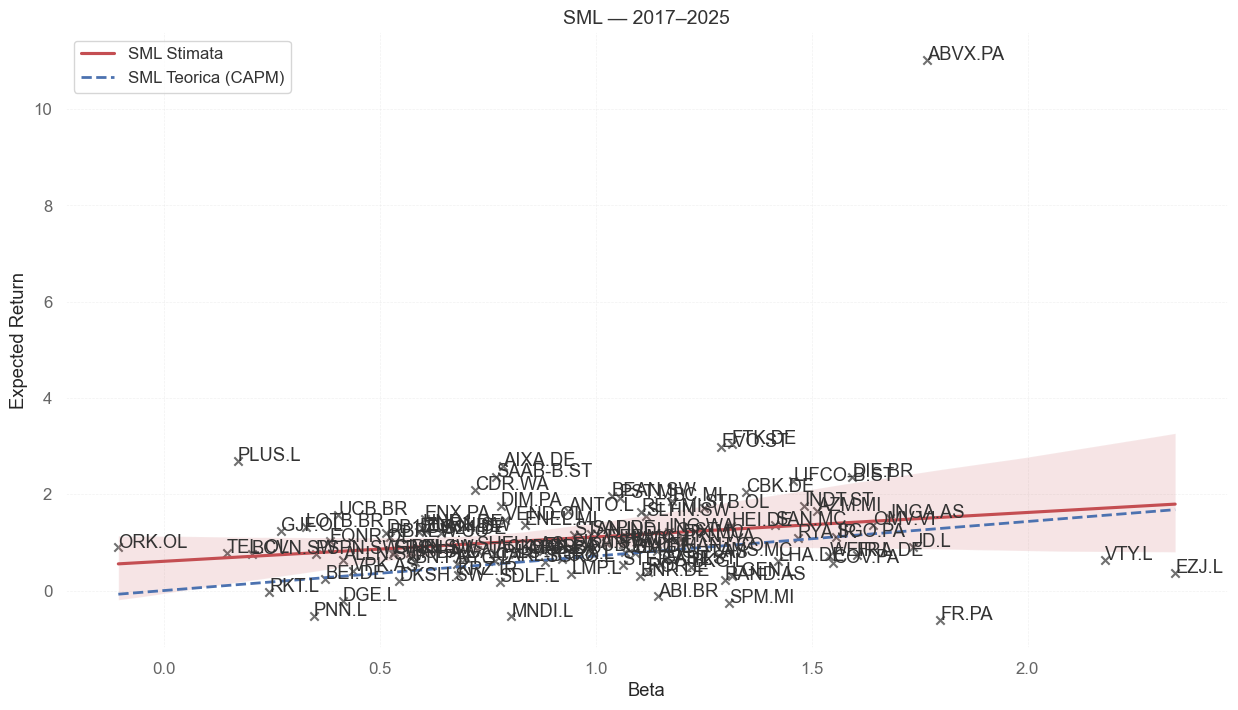

In [8]:
mkt_mean = new_data['Mkt-RF'].mean()
d_start = pd.to_datetime(start).year
d_end   = pd.to_datetime(end).year

plt.figure(figsize=(15, 8))

# SML stimata (regressione empirica)
ax = sns.regplot(x=betas, y=e_r, marker="x",
                 color=".3", line_kws=dict(color="r", label="SML Stimata"))

# Etichette titoli
for i, txt in enumerate(e_r.index):
    ax.annotate(txt, (betas.iloc[i], e_r.iloc[i]))

# SML teorica (pendenza = media premio di mercato, passa per l'origine)
beta_range   = np.linspace(betas.min(), betas.max(), 100)
sml_teorica  = beta_range * mkt_mean
plt.plot(beta_range, sml_teorica, 'b--', linewidth=2, label='SML Teorica (CAPM)')

plt.title(f'SML — {d_start}–{d_end}', fontsize=14)
plt.ylabel('Expected Return')
plt.xlabel('Beta')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### Commento

La Security Market Line stimata sull'intero periodo mostra una pendenza
positiva, confermando la relazione di fondo prevista dal CAPM: titoli con
beta più elevato tendono a offrire rendimenti medi superiori. Tuttavia,
la pendenza empirica risulta significativamente più ripida rispetto alla
SML teorica (rappresentata dalla linea tratteggiata blu), che ha come
pendenza la media del premio di mercato sul periodo. Questo suggerisce
che, nel campione analizzato, il mercato ha remunerato il rischio
sistematico in misura superiore a quanto previsto dalla teoria.

L'intercetta della retta stimata è leggermente negativa. Nel CAPM puro,
lavorando già con excess returns (rendimenti al netto del risk-free),
l'intercetta teorica dovrebbe essere zero. Un valore negativo indica che
i titoli a basso beta hanno mediamente sottoperformato rispetto alle
previsioni del modello.

La dispersione dei titoli attorno alla retta è molto elevata, come
evidenziato dall'ampia fascia di confidenza nel grafico. Questo basso
potere esplicativo del beta — coerente con un R² contenuto — segnala
che fattori diversi dal rischio di mercato (dimensione, valore,
momentum, rischio idiosincratico) contribuiscono in misura rilevante
alla spiegazione dei rendimenti cross-sezionali, limitando la validità
empirica del CAPM nella sua forma più semplice.

## PUNTO 3

In [9]:
sp1_start = '2017-01-01'
sp1_end   = '2019-12-31'

sp2_start = '2020-01-01'
sp2_end   = '2022-12-31'

sp3_start = '2023-01-01'
sp3_end   = '2025-12-31'

In [10]:
m1_sp1 = []
m1_sp2 = []
m1_sp3 = []

for i in range(1,len(new_data.columns)):
    m1_sp1.append(sm.OLS(new_data[new_data.columns[i]].loc[sp1_start:sp1_end], sm.add_constant(new_data['Mkt-RF'].loc[sp1_start:sp1_end])).fit())
    m1_sp2.append(sm.OLS(new_data[new_data.columns[i]].loc[sp2_start:sp2_end], sm.add_constant(new_data['Mkt-RF'].loc[sp2_start:sp2_end])).fit())
    m1_sp3.append(sm.OLS(new_data[new_data.columns[i]].loc[sp3_start:sp3_end], sm.add_constant(new_data['Mkt-RF'].loc[sp3_start:sp3_end])).fit())

In [11]:
# ── Estrazione beta, e_r e mkt_mean per ogni sottoperiodo ──────────────────
# (stesso pattern della cella 7 sul full sample)

# Sottoperiodo 1: 2017–2019
betas_p1 = pd.Series(
    [m1_sp1[i].params.iloc[1] for i in range(len(m1_sp1))],
    index=new_data.columns[1:]
)
e_r_p1 = new_data.iloc[:, 1:].loc[sp1_start:sp1_end].mean(axis=0)
mkt_p1  = new_data['Mkt-RF'].loc[sp1_start:sp1_end].mean()

# Sottoperiodo 2: 2020–2022
betas_p2 = pd.Series(
    [m1_sp2[i].params.iloc[1] for i in range(len(m1_sp2))],
    index=new_data.columns[1:]
)
e_r_p2 = new_data.iloc[:, 1:].loc[sp2_start:sp2_end].mean(axis=0)
mkt_p2  = new_data['Mkt-RF'].loc[sp2_start:sp2_end].mean()

# Sottoperiodo 3: 2023–2025
betas_p3 = pd.Series(
    [m1_sp3[i].params.iloc[1] for i in range(len(m1_sp3))],
    index=new_data.columns[1:]
)
e_r_p3 = new_data.iloc[:, 1:].loc[sp3_start:sp3_end].mean(axis=0)
mkt_p3  = new_data['Mkt-RF'].loc[sp3_start:sp3_end].mean()

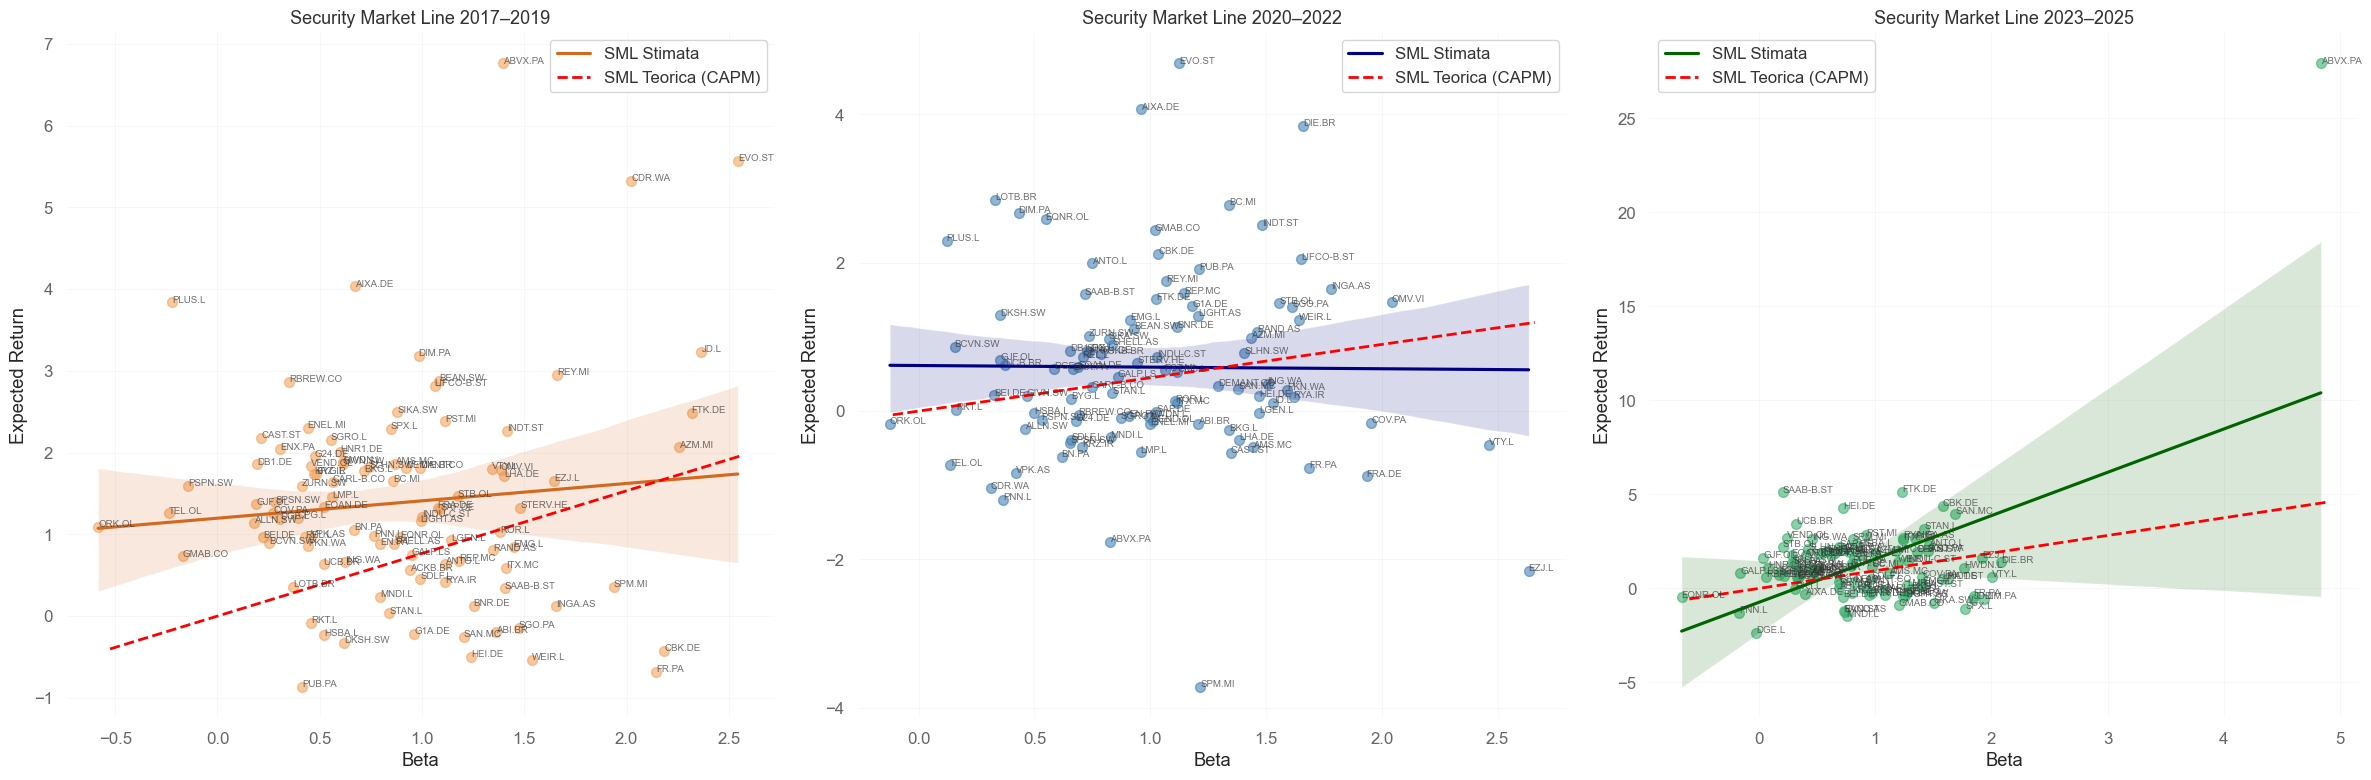

In [12]:
# ── Grafico SML per i 3 sottoperiodi ───────────────────────────────────────

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

periodi = [
    (betas_p1, e_r_p1, mkt_p1, '2017', '2019', ax1, 'sandybrown',  'chocolate'),
    (betas_p2, e_r_p2, mkt_p2, '2020', '2022', ax2, 'steelblue',   'navy'),
    (betas_p3, e_r_p3, mkt_p3, '2023', '2025', ax3, 'mediumseagreen', 'darkgreen'),
]

for betas, e_r, mkt, anno_start, anno_end, ax, col_scatter, col_line in periodi:

    # SML stimata (regressione)
    sns.regplot(x=betas, y=e_r, ax=ax,
                scatter_kws={'s': 50, 'alpha': 0.6, 'color': col_scatter},
                line_kws={'color': col_line, 'label': 'SML Stimata'})

    # SML teorica (CAPM: passa per l'origine, pendenza = media Mkt-RF)
    x_range = np.linspace(betas.min() * 0.9, betas.max() * 1.01, 100)
    sml_teorica = x_range * mkt
    ax.plot(x_range, sml_teorica, color='red', linestyle='--',
            linewidth=2, label='SML Teorica (CAPM)')

    # Etichette ticker
    for i, txt in enumerate(e_r.index):
        ax.annotate(txt, (betas.iloc[i], e_r.iloc[i]), fontsize=7, alpha=0.7)

    ax.set_title(f'Security Market Line {anno_start}–{anno_end}', fontsize=13)
    ax.set_xlabel('Beta')
    ax.set_ylabel('Expected Return')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Commento

#### Periodo 2017–2019
Nel primo triennio il mercato europeo ha vissuto una fase di espansione
moderata, caratterizzata da politica monetaria accomodante della BCE
(tassi negativi e QE) e crescita economica stabile. La SML stimata mostra
una pendenza leggermente positiva ma molto vicina a zero. 
La relazione beta-rendimento è quindi quasi assente:
i titoli ad alto e basso beta hanno reso in modo simile, un risultato
coerente con un contesto di bassi tassi in cui la compressione dei premi
al rischio riduce il potere discriminante del beta. La dispersione dei
titoli attorno alla retta è contenuta rispetto ai periodi successivi.

#### Periodo 2020–2022
Il secondo triennio è il più anomalo. La SML stimata è sostanzialmente
piatta, pendenza prossima a zero. Questo
risultato riflette la straordinaria eterogeneità degli shock che hanno
caratterizzato il periodo: il crollo violento dei mercati nel primo
trimestre 2020 a causa della pandemia Covid-19, seguito da un rimbalzo
altrettanto brusco sostenuto dagli interventi massicci di BCE e governi,
e infine la fase di forte rialzo inflattivo e il successivo ciclo di
stretta monetaria avviato nel 2022 in risposta alla guerra in Ucraina.
In questo contesto, il rendimento medio dei titoli è stato determinato
quasi interamente da fattori settoriali e idiosincratici — titoli
farmaceutici e tecnologici hanno beneficiato della pandemia, titoli
energetici del rialzo delle materie prime — rendendo il beta un
predittore del tutto inefficace. La dispersione attorno alla retta è
la più elevata dei tre periodi, con numerosi titoli molto lontani dalla
SML in entrambe le direzioni.

#### Periodo 2023–2025
Nel terzo triennio la relazione beta-rendimento si ristabilisce in modo
netto. La SML stimata mostra la pendenza più ripida dei tre sottoperiodi. 
In una fase di normalizzazione
monetaria — con la BCE che avvia i tagli dei tassi a partire dal 2024 —
e di mercati più ordinati, il rischio sistematico torna a essere
remunerato in modo differenziato: i titoli ad alto beta sovraperformano
quelli a basso beta in misura coerente con le previsioni del CAPM.
L'intercetta negativa segnala però che i titoli a beta molto basso
continuano a sottoperformare rispetto alla retta teorica, confermando
la persistenza della low-beta anomaly anche in questa fase.

#### Considerazioni
L'analisi per sottoperiodi evidenzia chiaramente come la validità
empirica del CAPM sul mercato europeo sia fortemente dipendente dal
regime macroeconomico. In periodi di shock eccezionali e alta volatilità
(2020–2022) il modello perde quasi completamente il suo potere
esplicativo, mentre in contesti più stabili (2023–2025) la relazione
rischio-rendimento prevista dalla teoria emerge con maggiore nitidezza.

## PUNTO 4

In [13]:
# ── Costruzione DataFrame con dummy temporale (struttura richiesta dall'homework) ──

# Sottoperiodo 1
df_p1 = pd.DataFrame({
    'Ticker':       betas_p1.index,
    'Beta':         betas_p1.values,
    'Rendimento':   e_r_p1.values,
    'Periodo':      '2017 - 2019'
})

# Sottoperiodo 2
df_p2 = pd.DataFrame({
    'Ticker':       betas_p2.index,
    'Beta':         betas_p2.values,
    'Rendimento':   e_r_p2.values,
    'Periodo':      '2020 - 2022'
})

# Sottoperiodo 3
df_p3 = pd.DataFrame({
    'Ticker':       betas_p3.index,
    'Beta':         betas_p3.values,
    'Rendimento':   e_r_p3.values,
    'Periodo':      '2023 - 2025'
})

# Accodamento verticale dei tre sottoperiodi
df_risultati = pd.concat([df_p1, df_p2, df_p3], ignore_index=True)

# ── Grafico Plotly interattivo con animation_frame ──────────────────────────
df_plot = df_risultati.dropna(subset=['Beta', 'Rendimento'])

fig = px.scatter(
    df_plot,
    x='Beta',
    y='Rendimento',
    animation_frame='Periodo',
    hover_name='Ticker',
    text='Ticker',
    trendline='ols',
    title='SML Empirica Dinamica — Mercato Europeo'
)

fig.show()